# Sequence analysis: from binary sequences to H, P, Z(H), and Z(P)

This notebook gives a compact walkthrough of the sequence-pattern metrics used in this project.

It does three things:

1. represents sequences as binary sticker–spacer strings,
2. computes raw dispersion and patchiness metrics (`H` and `P`) using the repository's production code,
3. normalizes those raw values to `Z(H)` and `Z(P)` using precomputed lookup tables.

This notebook is intentionally limited to metric definition and normalization. The biological applications to real PLCD and nuclear IDR sequences are described elsewhere.

Example sticker rules used in this project:
- PLCDs: `Y`, `F`, `R`
- nuclear IDRs: `E`, `K`



In [1]:
from pathlib import Path
import sys
import os
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- locate repository root robustly ----
cwd = Path.cwd().resolve()

# expected notebook location: repo_root/notebooks/sequence_analysis.ipynb
if cwd.name == "notebooks":
    ROOT = cwd.parent
elif (cwd / "SequenceDesign").exists():
    ROOT = cwd
else:
    # fallback: walk upward until SequenceDesign exists
    ROOT = cwd
    while ROOT != ROOT.parent and not (ROOT / "SequenceDesign").exists():
        ROOT = ROOT.parent

SEQDESIGN_DIR = ROOT / "SequenceDesign" / "ZHP_N70_S20_parallel"

if not SEQDESIGN_DIR.exists():
    raise FileNotFoundError(
        "Could not find SequenceDesign/ZHP_N70_S20_parallel. "
        "Run this notebook from the StickerPatterning repo."
    )

if str(SEQDESIGN_DIR) not in sys.path:
    sys.path.insert(0, str(SEQDESIGN_DIR))

print("Repository root:", ROOT)
print("Sequence metric directory:", SEQDESIGN_DIR)

Repository root: /Users/davidkanovich/GitHub/StickerPatterning
Sequence metric directory: /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel


## Files used in this notebook

This notebook uses the repository's existing metric code and lookup tables:

- `PatternMetric.py` for raw metric computation
- `NormMetric.py` for normalization
- `H_Z_lookup_100k.pkl`
- `P_Z_lookup_100k.pkl`

The goal here is to demonstrate the workflow, not to reimplement the analysis from scratch.

In [2]:
import PatternMetric
import NormMetric

print("Imported PatternMetric from:", Path(PatternMetric.__file__).resolve())
print("Imported NormMetric from:", Path(NormMetric.__file__).resolve())

Imported PatternMetric from: /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel/PatternMetric.py
Imported NormMetric from: /Users/davidkanovich/GitHub/StickerPatterning/SequenceDesign/ZHP_N70_S20_parallel/NormMetric.py


## Binary sticker–spacer representation

Throughout this notebook:

- `1` = sticker
- `0` = spacer

The toy examples below are defined directly as binary **strings**. This keeps the notebook aligned with the production code, which expects sequence strings rather than Python lists or arrays.



In [3]:
toy_sequences = {
    "terminal": "11111111000000000000",
    "extreme": "11110000000000001111",
    "patchy": "11001100110011000000",
    "uniform_clustered": "10101010101010000000",
    "uniform_dispersed": "10010010010010010010",
}

def seq_to_mask(seq):
    return np.array([int(x) for x in seq], dtype=int)

def seq_to_glyphs(seq):
    return "".join("●" if x == "1" else "·" for x in seq)

def count_stickers(seq):
    return seq.count("1")

summary_rows = []
for name, seq in toy_sequences.items():
    summary_rows.append({
        "name": name,
        "sequence": seq,
        "visual": seq_to_glyphs(seq),
        "L": len(seq),
        "k": count_stickers(seq),
        "sticker_fraction": count_stickers(seq) / len(seq),
    })

pd.DataFrame(summary_rows)



,name,sequence,visual,L,k,sticker_fraction
0,terminal,11111111000000000000,●●●●●●●●············,20,8,0.40
1,extreme,11110000000000001111,●●●●············●●●●,20,8,0.40
2,patchy,11001100110011000000,●●··●●··●●··●●······,20,8,0.40
3,uniform_clustered,10101010101010000000,●·●·●·●·●·●·●·······,20,7,0.35
4,uniform_dispersed,10010010010010010010,●··●··●··●··●··●··●·,20,7,0.35


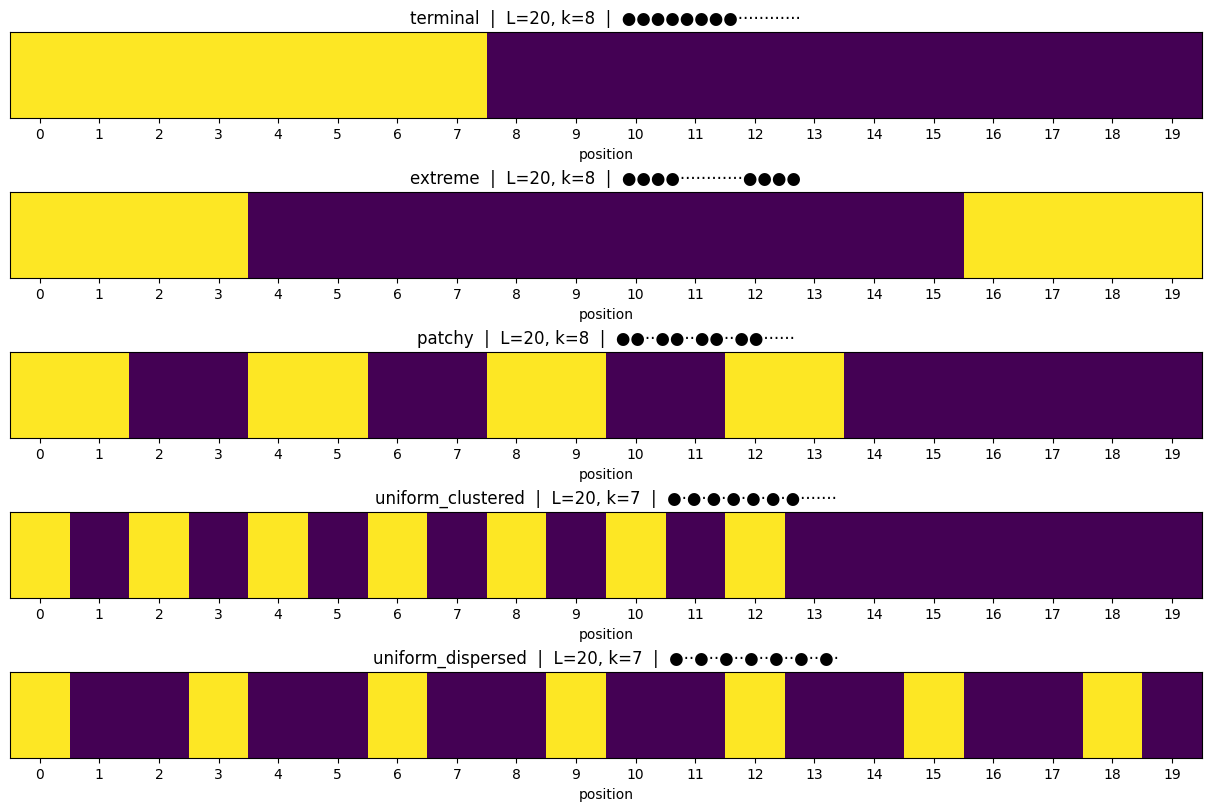

In [4]:
fig, axes = plt.subplots(len(toy_sequences), 1, figsize=(12, 1.6 * len(toy_sequences)), constrained_layout=True)

if len(toy_sequences) == 1:
    axes = [axes]

for ax, (name, seq) in zip(axes, toy_sequences.items()):
    mask = seq_to_mask(seq)
    ax.imshow(mask[np.newaxis, :], aspect="auto")
    ax.set_yticks([])
    ax.set_xticks(np.arange(len(seq)))
    ax.set_title(f"{name}  |  L={len(seq)}, k={count_stickers(seq)}  |  {seq_to_glyphs(seq)}")
    ax.set_xlabel("position")

plt.show()



## Raw dispersion metric: H

`H` is the raw dispersion metric computed from the binary sequence using the repository's production code in `PatternMetric.py`.

Conceptually, it measures how dispersed stickers are along the sequence. More spread-out stickers give higher dispersion than tightly clustered stickers.



In [5]:
print("PatternMetric contents:")
print([name for name in dir(PatternMetric) if not name.startswith("_")][:50])

PatternMetric contents:
['StickerPattern', 'arange', 'array', 'diff', 'log', 'ma', 'mean', 'np']


In [6]:
def compute_raw_metrics_with_patternmetric(seq):
    """
    Compute raw H and P from a binary sequence string using the repository's
    production PatternMetric code. The sticker character is "1".
    """
    obj = PatternMetric.StickerPattern(seq, "1")
    H_raw = obj.calc_H_ave()
    P_raw = obj.process_patch()
    return H_raw, P_raw

raw_rows = []
for name, seq in toy_sequences.items():
    H_raw, P_raw = compute_raw_metrics_with_patternmetric(seq)
    raw_rows.append({
        "name": name,
        "sequence": seq,
        "visual": seq_to_glyphs(seq),
        "L": len(seq),
        "k": count_stickers(seq),
        "H_raw": H_raw,
        "P_raw": P_raw,
    })

raw_df = pd.DataFrame(raw_rows).sort_values("H_raw")
raw_df



,name,sequence,visual,L,k,H_raw,P_raw
0,terminal,11111111000000000000,●●●●●●●●············,20,8,0.561253,1.000000
1,extreme,11110000000000001111,●●●●············●●●●,20,8,0.561253,0.857143
3,uniform_clustered,10101010101010000000,●·●·●·●·●·●·●·······,20,7,0.837691,0.000000
2,patchy,11001100110011000000,●●··●●··●●··●●······,20,8,0.890827,0.571429
4,uniform_dispersed,10010010010010010010,●··●··●··●··●··●··●·,20,7,0.969034,0.000000


## Raw patchiness metric: P

`P` is the raw patchiness metric from `PatternMetric.py`.

Conceptually, it captures local sticker clustering. Sequences with adjacent or blocky stickers tend to have higher patchiness than more evenly dispersed sequences.

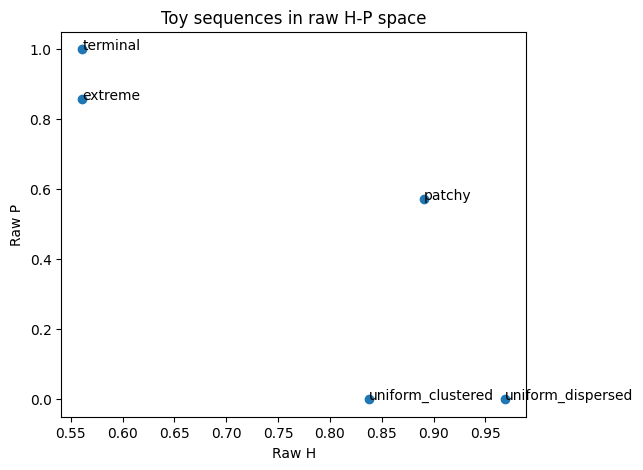

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(raw_df["H_raw"], raw_df["P_raw"])

for _, row in raw_df.iterrows():
    ax.text(row["H_raw"], row["P_raw"], row["name"])

ax.set_xlabel("Raw H")
ax.set_ylabel("Raw P")
ax.set_title("Toy sequences in raw H-P space")
plt.show()

## Why normalization is needed

Raw `H` and `P` depend on sequence composition, especially sequence length (`L`) and sticker count (`k`).

To compare sequences fairly, the raw values are normalized against shuffled-reference expectations for the same `(L, k)` combination. In this project, that normalization is handled by `NormMetric.py` using precomputed lookup tables. These tables contain the standard deviation and mean of 100 thousand shuffled sequences for each combination `(L, k)` up to `L = 200`



In [8]:
H_LOOKUP = SEQDESIGN_DIR / "H_Z_lookup_100k.pkl"
P_LOOKUP = SEQDESIGN_DIR / "P_Z_lookup_100k.pkl"

with open(H_LOOKUP, "rb") as f:
    H_lookup = pickle.load(f)

with open(P_LOOKUP, "rb") as f:
    P_lookup = pickle.load(f)

print("Loaded H lookup type:", type(H_lookup))
print("Loaded P lookup type:", type(P_lookup))
print("Number of H lookup entries:", len(H_lookup))
print("Number of P lookup entries:", len(P_lookup))

# peek at one key
H_first_key = next(iter(H_lookup))
P_first_key = next(iter(P_lookup))

print("Example H lookup key:", H_first_key)
print("Example P lookup key:", P_first_key)
print("Example H lookup value:", H_lookup[H_first_key])
print("Example P lookup value:", P_lookup[P_first_key])

Loaded H lookup type: <class 'dict'>
Loaded P lookup type: <class 'dict'>
Number of H lookup entries: 195
Number of P lookup entries: 200
Example H lookup key: 6
Example P lookup key: 1
Example H lookup value: {0: (0.0, 0.0), 1: (0.500656008720398, 0.24102066457271576), 2: (0.8897178173065186, 0.09689764678478241), 3: (0.9612811803817749, 0.019974708557128906), 4: (0.982857882976532, 0.006828242912888527), 5: (0.9935925006866455, 0.002780875889584422), 6: (1.0, 0.0)}
Example P lookup value: {0: (0.0, 0.0), 1: (0.0, 0.0)}


In [9]:
def compute_normalized_metrics_with_normmetric(seq):
    """
    Compute raw and normalized metrics from a binary sequence string.
    The sticker character is "1".
    """
    H_raw = PatternMetric.StickerPattern(seq, "1").calc_H_ave()
    P_raw = PatternMetric.StickerPattern(seq, "1").process_patch()

    Z_H = NormMetric.normalised_H(
        seq,
        sticker="1",
        lookup_path=str(SEQDESIGN_DIR / "H_Z_lookup_100k.pkl"),
    )
    Z_P = NormMetric.normalised_P(
        seq,
        sticker="1",
        lookup_path=str(SEQDESIGN_DIR / "P_Z_lookup_100k.pkl"),
    )

    return H_raw, P_raw, Z_H, Z_P

norm_rows = []
for name, seq in toy_sequences.items():
    try:
        H_raw, P_raw, Z_H, Z_P = compute_normalized_metrics_with_normmetric(seq)
        norm_rows.append({
            "name": name,
            "sequence": seq,
            "visual": seq_to_glyphs(seq),
            "L": len(seq),
            "k": count_stickers(seq),
            "H_raw": H_raw,
            "P_raw": P_raw,
            "Z_H": Z_H,
            "Z_P": Z_P,
        })
    except Exception as e:
        norm_rows.append({
            "name": name,
            "sequence": seq,
            "visual": seq_to_glyphs(seq),
            "L": len(seq),
            "k": count_stickers(seq),
            "H_raw": np.nan,
            "P_raw": np.nan,
            "Z_H": np.nan,
            "Z_P": np.nan,
            "error": str(e),
        })

norm_df = pd.DataFrame(norm_rows)
norm_df



,name,sequence,visual,L,k,H_raw,P_raw,Z_H,Z_P
0,terminal,11111111000000000000,●●●●●●●●············,20,8,0.561253,1.000000,-5.565760,3.925479
1,extreme,11110000000000001111,●●●●············●●●●,20,8,0.561253,0.857143,-5.565760,2.991610
2,patchy,11001100110011000000,●●··●●··●●··●●······,20,8,0.890827,0.571429,0.036775,1.123873
3,uniform_clustered,10101010101010000000,●·●·●·●·●·●·●·······,20,7,0.837691,0.000000,-0.300815,-2.092592
4,uniform_dispersed,10010010010010010010,●··●··●··●··●··●··●·,20,7,0.969034,0.000000,1.562059,-2.092592


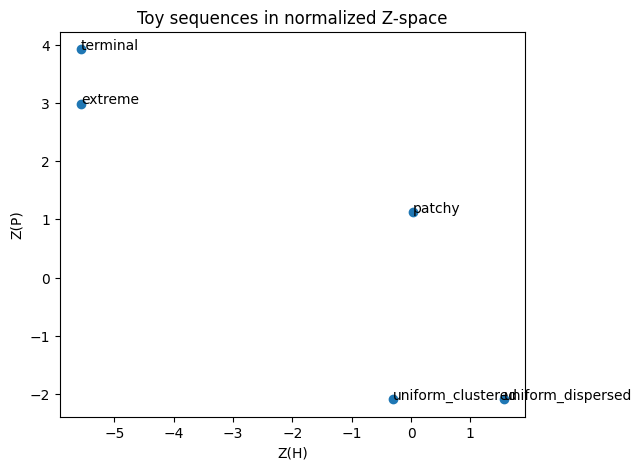

In [10]:
valid_norm_df = norm_df.dropna(subset=["Z_H", "Z_P"]).copy()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(valid_norm_df["Z_H"], valid_norm_df["Z_P"])

for _, row in valid_norm_df.iterrows():
    ax.text(row["Z_H"], row["Z_P"], row["name"])

ax.set_xlabel("Z(H)")
ax.set_ylabel("Z(P)")
ax.set_title("Toy sequences in normalized Z-space")
plt.show()

In [11]:
example_plcd_seq = "GYGSFRGGY"
plcd_stickers = {"Y", "F", "R"}

example_binary_seq = "".join("1" if aa in plcd_stickers else "0" for aa in example_plcd_seq)

print("Example amino-acid sequence:", example_plcd_seq)
print("Sticker rule: Y/F/R")
print("Binary sequence:       ", example_binary_seq)
print("Visual pattern:        ", seq_to_glyphs(example_binary_seq))

H_raw, P_raw = compute_raw_metrics_with_patternmetric(example_binary_seq)
print("Raw H:", H_raw)
print("Raw P:", P_raw)

try:
    H_raw2, P_raw2, Z_H, Z_P = compute_normalized_metrics_with_normmetric(example_binary_seq)
    print("Z(H):", Z_H)
    print("Z(P):", Z_P)
except Exception as e:
    print("Normalization failed:", e)



Example amino-acid sequence: GYGSFRGGY
Sticker rule: Y/F/R
Binary sequence:        010011001
Visual pattern:         ·●··●●··●
Raw H: 0.9725755918833674
Raw P: 0.3333333333333333
Z(H): 0.7816764954295401
Z(P): -0.45216117068039735
